# Block C, Year 1: Deep Learning Template

Name: Asma_moghimi

Number: 240791

Please, use this template implement and document your solutions to the Deep Learning tasks as described in the [DataLab Tasks](https://adsai.buas.nl/Year1/BlockC/DataLabTasks.html) page. If you have any questions, please, contact your mentor or the content responsible. 

## Important Notes:
- [ ] Please, rename the file to ```Deep-Learning-YOUR_NAME-STUDENT_NUMBER.ipynb```. 
- [ ] You are allowed to add as many Markdown/Python cells as you need. 
- [ ] You are required to provide textual explanations on all tasks. Please use the markdown cells to explain all your decisions while building your image classification model.
- [ ] If more iteration steps were performed while building your model, please add more iteration sections in the template.
- [ ] If certain Markdown/Python cells were not used, please remove them from the final version of your file. 
- [ ] You must replace the instructions in the template sections with your own content.
- [ ] Your work must be reproducible, meaning that we should be able to run your code in the template and get similar results to yours. Tip: use relative paths to load your data!
- [ ] Ensure that before you hand in the template, you press ```Restart & Run all```; we should be able to see the results of your code in the notebook (i.e., output cells).
- [ ] Ensure that your code in the template is ```error-free```. In other words, we should not see any error messages when we run your code.

## Task 3.1: Create an Image Dataset

To build the dataset, I explored multiple approaches to obtain images of **defective and non-defective fabric samples**:

#### 1.1) Collecting Images from the Factory

Since there were not enough images available online, I visited **[Petro Baspar Co.](http://petrobasparco.ir)**, a fabric manufacturing factory, and captured about **half of the dataset myself**. This allowed me to collect **both defective and non-defective fabric images** in a real production setting, ensuring **greater accuracy and reliability** for the project. 


#### 1.2) Web Scraping Approach  

To supplement my dataset, I manually downloaded images using **[Imageye](https://chrome.google.com/webstore/detail/imageye-image-downloader/agionbommeaifngbhincahgmoflcikhm)**, a Chrome image downloader extension, to ensure the **best format and resolution**. I focused on collecting **high-quality non-defective fabric textures** from the following sources:  

- **[iStock](https://www.istockphoto.com/)**  
- **[Freepik](https://www.freepik.com/)**  
- **[EU Fabrics](https://www.eufabrics.com/)**  
- **[Alibaba](https://www.alibaba.com/)** 
- **[Roboflow Universe](https://universe.roboflow.com/)**  
 

These sources provided **close-up fabric textures**, which were particularly useful for gathering **non-defective samples**. However, **finding defective fabric images online was challenging**, as most available images focused on **product display rather than manufacturing defects**.  



#### 1.3) Using Existing Datasets
To build a comprehensive dataset for defect detection, I incorporated **defective fabric images** from publicly available sources. Specifically, I used some images from the **[Fabric Defect Dataset](https://www.kaggle.com/datasets/rmshashi/fabric-defect-dataset)** on Kaggle.  

This dataset contains images of fabrics with various defects, including **holes, stains, and structural anomalies**, along with corresponding mask images for defect localization. The images were selected based on their relevance to my project, ensuring a diverse set of **real-world defective fabric samples**.  

#### 1.4) websocket-Generated Defective Fabric Images

```python
import websocket
print("Websocket library installed correctly.")

import uuid
import json
import urllib
import random
import io
import os
import websocket
from IPython.display import Image, display
import base64

comfyui_server_address = "buas3.edirlei.com"
comfyui_workflow_path = "./workflow_flux_api.json"
comfyui_client_id = str(uuid.uuid4())
comfyui_username = "adsai"
comfyui_password = "wcN5tui9oR0sCAE9FrgIdJPhMiElJjBwQwLzn57buf"
comfyui_credentials = base64.b64encode(f"{comfyui_username}:{comfyui_password}".encode('utf-8')).decode('utf-8')
comfyui_auth_header = f"Basic {comfyui_credentials}"

def comfyui_queue_prompt(prompt):
    p = {"prompt": prompt, "client_id": comfyui_client_id}
    data = json.dumps(p).encode('utf-8')
    req = urllib.request.Request(f"http://{comfyui_server_address}/prompt", data=data, headers = {"Authorization": comfyui_auth_header})
    return json.loads(urllib.request.urlopen(req).read())

def comfyui_get_image(filename, subfolder, folder_type):
    data = {"filename": filename, "subfolder": subfolder, "type": folder_type}
    url_values = urllib.parse.urlencode(data)
    req = urllib.request.Request(f"http://{comfyui_server_address}/view?{url_values}", headers = {"Authorization": comfyui_auth_header})
    with urllib.request.urlopen(req) as response:
        return response.read()

def comfyui_get_history(prompt_id):
    req = urllib.request.Request(f"http://{comfyui_server_address}/history/{prompt_id}", headers = {"Authorization": comfyui_auth_header})
    with urllib.request.urlopen(req) as response:
        return json.loads(response.read())

def comfyui_get_images(ws, prompt):
    prompt_id = comfyui_queue_prompt(prompt)['prompt_id']
    output_images = {}
    while True:
        out = ws.recv()
        if isinstance(out, str):
            message = json.loads(out)
            if message['type'] == 'executing':
                data = message['data']
                if data['node'] is None and data['prompt_id'] == prompt_id:
                    break
        else:
            continue

    history = comfyui_get_history(prompt_id)[prompt_id]
    for o in history['outputs']:
        for node_id in history['outputs']:
            node_output = history['outputs'][node_id]
            if 'images' in node_output:
                images_output = []
                for image in node_output['images']:
                    image_data = comfyui_get_image(image['filename'], image['subfolder'], image['type'])
                    images_output.append(image_data)
            output_images[node_id] = images_output

    return output_images

def comfyui_generate_image_flux(prompt, seed, output_filename):
    with open(comfyui_workflow_path, "r") as file:
        workflowdata = json.load(file)

    if seed == -1:
        seed = random.randint(0, 2**32 - 1)

    # depending on the workflow used, these nodes need to be adjusted (open file workflow_flux_api.json to see all nodes)
    workflowdata["6"]["inputs"]["text"] = prompt
    workflowdata["25"]["inputs"]["noise_seed"] = seed

    ws = websocket.WebSocket()
    ws.connect("ws://{}/ws?clientId={}".format(comfyui_server_address, comfyui_client_id), header={"Authorization": comfyui_auth_header})
    images = comfyui_get_images(ws, workflowdata)

    if len(images) > 0:
        bytestream = io.BytesIO(images["9"][0])
        with open(output_filename, "wb") as outfile:
            outfile.write(bytestream.getbuffer())

comfyui_generate_image_flux("A serene lakeside at sunset", -1, "my_first_test_comfyui.png")

display(Image(filename="my_first_test_comfyui.png", width=500))

class_prompts["defect"].extend([
    "A close-up view of smooth, evenly textured blue nonwoven fabric with a uniform fiber pattern and no visible defects.",
    "A detailed shot of synthetic nonwoven material with a fine, perforated texture, evenly spread across the entire surface.",
    "A high-resolution view of a clean, seamless piece of Spunbond nonwoven fabric, showing its characteristic mesh-like texture.",
    "A well-lit textile surface with a consistent nonwoven pattern, highlighting the soft and breathable material structure.",
    "A plain sheet of industrial nonwoven fabric with an even surface, free from holes, stains, or irregularities."

    "A close-up view of blue nonwoven fabric with irregular holes and torn fibers, revealing inconsistencies in the material's structure."
    "A high-resolution image of Spunbond nonwoven fabric with visible stains, uneven fiber distribution, and frayed edges, highlighting quality defects."
    "A macro shot of synthetic nonwoven fabric with a rough, inconsistent texture, featuring loose fibers and small punctures scattered across the surface."
    "A detailed view of industrial nonwoven fabric with a noticeable tear running across the material, exposing frayed fibers and a weakened structure."
    "A damaged piece of nonwoven textile with visible burn marks, discoloration, and irregular fiber density, illustrating common manufacturing defects."

    "A close-up of nonwoven fabric with visible wrinkles, creases, and uneven fiber distribution, indicating manufacturing defects."  
    "A high-resolution view of white nonwoven fabric with noticeable dark stains and dirt patches spread across the surface."  
    "A detailed macro shot of Spunbond nonwoven material with a torn section, showing frayed fibers and an uneven edge."  
    "A textured piece of nonwoven fabric with irregular perforations and scattered holes, making the surface appear weak and damaged."  
    "A zoomed-in shot of synthetic nonwoven fabric with color inconsistencies, where some areas appear faded while others are overly saturated."  
    "A nonwoven textile sample with a rough, patchy texture, featuring clumped fibers and inconsistent material thickness."  
    "A close-up of industrial nonwoven fabric with loose fibers protruding from the surface, giving it an untidy and defective appearance."  
    "A damaged sheet of nonwoven fabric with an uneven weave pattern, where certain sections are denser while others are too sparse."  
    "A poorly manufactured Spunbond fabric with thread pulls and fiber misalignment, creating an irregular, messy pattern."  
    "A defective roll of nonwoven fabric with melted or heat-damaged sections, causing distortion in the material’s texture and structure."  


])

# number of images to generate per class
num_images_per_class = 20

# additional prompt to ensure that only realistic images are generated
realistic_style_prompt = "Photography, highly detailed, sharp focus, hyperrealism."

# create a subfolder to store the generated dataset
os.makedirs(".//dataset", exist_ok=True)
for category, prompts in class_prompts.items():
     # create a subfolder for the category
     os.makedirs(".//dataset//" + category, exist_ok=True)

     for i in range(num_images_per_class):
          # pick a random prompt from the list of prompts
          random_prompt = prompts[random.randint(0, len(prompts) - 1)]

          # generate and save the image
          image_filename = ".//dataset//" + category + "//" + category + "_" + str(i + 1) + ".png"
          comfyui_generate_image_flux(random_prompt + " " + realistic_style_prompt, -1, image_filename)
          print("Generated image: " + image_filename)





### B: Dataset Cleaning

I used this code to convert all images in my dataset to JPEG format to maintain consistency across the dataset. Some images were in PNG format, which could cause compatibility issues during processing.


```python
from PIL import Image
import os

# Folder containing PNG images (Set your path)
folder_path = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/image_dataset/Defective_Fabric"

# Loop through all PNG images in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(".png"):
        # Full path of the original PNG
        file_path = os.path.join(folder_path, filename)

        # Open the PNG image and convert to RGB
        img = Image.open(file_path).convert("RGB")

        # Generate new filename with .jpg extension
        new_file_path = os.path.splitext(file_path)[0] + ".jpg"

        # Save as JPEG (overwrite existing PNG)
        img.save(new_file_path, "JPEG", quality=95)

        # Delete the original PNG file
        os.remove(file_path)

print("PNG images converted to JPEG and replaced!")


I used this code to check for duplicate images in my dataset by generating a **perceptual hash** for each image. The script scans all images in the specified folder, computes a unique **hash value** for each image, and compares it against previously stored hashes. If a duplicate is detected, it is counted and reported. This helps ensure that my dataset contains only unique images, preventing redundancy and improving the efficiency of further processing.


```python
import os
import imagehash
from PIL import Image

# Folder where images are stored
image_folder = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/image_dataset"

# Dictionary to store unique image hashes
hashes = {}
duplicate_count = 0  # Counter for duplicate images

# Loop through all images in the folder
for filename in os.listdir(image_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        file_path = os.path.join(image_folder, filename)

        # Open image and generate hash
        img = Image.open(file_path)
        img_hash = imagehash.phash(img)  # Perceptual hash

        # Check if the hash exists (duplicate)
        if img_hash in hashes:
            print(f"Duplicate found: {filename} is a duplicate of {hashes[img_hash]}")
            duplicate_count += 1  # Increment duplicate count
        else:
            hashes[img_hash] = filename  # Store unique image hash

# Display total duplicate count
print(f"Duplicate image check complete. Found {duplicate_count} duplicate images.")


This code checks for **blurry images** in the dataset by calculating the **Laplacian variance** of each image. It scans all images in the specified folder, converts them to grayscale, and computes their **variance using the Laplacian operator**. If an image has a variance below the defined **blurriness threshold (100)**, it is considered blurry and counted. This helps identify and filter out low-quality images, ensuring that the dataset consists of **clear and sharp images** suitable for further processing or model training.

```python
import cv2
import os

# Folder containing images
image_folder = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/image_dataset"

# Blurriness threshold (Adjust if needed)
blur_threshold = 100
blurry_count = 0  # Counter for blurry images

for filename in os.listdir(image_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        file_path = os.path.join(image_folder, filename)

        # Read image
        img = cv2.imread(file_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Compute Laplacian variance (blurriness score)
        variance = cv2.Laplacian(gray, cv2.CV_64F).var()

        if variance < blur_threshold:
            print(f"Blurry image detected: {filename} (Variance: {variance})")
            blurry_count += 1  # Increment blurry image count

# Display total blurry count
print(f"Blurry image check complete. Found {blurry_count} blurry images.")


This code ensures that all **JPEG images** in the dataset are in **RGB format**. It scans through the specified folder, checks each image, and verifies its color mode. If an image is **not in RGB mode**, it is converted to **RGB** and saved back in the same location, overwriting the original file. This process helps maintain consistency in the dataset, preventing potential errors when processing images in machine learning models that expect RGB input.


```python
from PIL import Image
import os

# Folder containing JPEG images
image_folder = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/image_dataset"

for filename in os.listdir(image_folder):
    if filename.lower().endswith(('.jpg', '.jpeg')):  # Only process JPEG files
        file_path = os.path.join(image_folder, filename)

        # Open the image
        img = Image.open(file_path)

        # Ensure the image is in RGB mode
        if img.mode != "RGB":
            print(f"Non-RGB image detected: {filename} - Converting to RGB")

            # Convert to RGB
            img = img.convert("RGB")

            # Save the new image, overwriting the original JPEG
            img.save(file_path, "JPEG")

print("Image format check complete. All images are now in RGB format.")


### C: Final Dataset

I have uploaded the image dataset to **BUas SharePoint**. You can access it using the following link:  
[BUas SharePoint Dataset](https://edubuas-my.sharepoint.com/:f:/g/personal/240791_buas_nl/Ehag8_39pbdPrOZ-lBgn7akB0KTpOke5QHo3eezf5EcZzg?e=wE5NHb)


### D: Load and Split

- Step 1 : I imported the libraries I needed, like os, shutil, and train_test_split from sklearn.
- Step 2 : I set the path to my original image dataset, and I also created an output path where I wanted the split dataset folders to be saved.
- Step 3 : I defined how I wanted to split my dataset: 70% for training, 20% for validation, and 10% for testing.
- Step 4 : I created empty folders named train, val, and test inside the output directory.
- Step 5 : I looped through each class in my dataset (like defective and non_defective) and made sure it was a valid folder.
- Step 6 : I collected the image file names from each class folder, only picking .jpg, .jpeg, and .png files.
- Step 7 : I used train_test_split to split the images into training, validation, and test sets.
- Step 8 : For each split (train/val/test), I created a subfolder and copied the images into their respective folders.
- Step 9 : I printed how many images were placed into each split for every class. This helped me check if the split worked correctly.
- Step 10 : Successfully split and ready to use.





In [ ]:
# Step 1
import os
import shutil
from sklearn.model_selection import train_test_split

# Step 2
dataset_folder = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/image_dataset"
output_folder = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/split_dataset"

# Step 3
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

# Step 4
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_folder, split), exist_ok=True)

# Step 5
for class_name in os.listdir(dataset_folder):
    class_path = os.path.join(dataset_folder, class_name)
    if not os.path.isdir(class_path):
        continue

# Step 6
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(images) == 0:
        continue

# Step 7
    train_imgs, temp_imgs = train_test_split(images, test_size=(1 - train_ratio), random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=(test_ratio / (val_ratio + test_ratio)), random_state=42)

# Step 8
    for split_name, img_list in zip(["train", "val", "test"], [train_imgs, val_imgs, test_imgs]):
        split_class_path = os.path.join(output_folder, split_name, class_name)
        os.makedirs(split_class_path, exist_ok=True)

        for img in img_list:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_path, img)
            shutil.copy(src, dst)

# Step 9
    print(f"{class_name}: {len(train_imgs)} train | {len(val_imgs)} val | {len(test_imgs)} test")

# Step 10
print(" Dataset successfully split into train, val, and test folders.")


Non_Defective_Fabric: 209 train | 60 val | 31 test
Defective_Fabric: 209 train | 60 val | 31 test
 Dataset successfully split into train, val, and test folders.


## Task 3.2: Calculate Baselines

### A: Random Guess Accuracy

- Step 1 : I define how many classes I have in my dataset. In this case, it's 2 — one for defective_fabric and one for non_defective_fabric. This calculates the baseline accuracy I would get if I guessed randomly. Since there are two classes, random guessing gives a 50% chance of being correct.  I print the random guess baseline accuracy as a percentage (with 2 decimal points).

In [5]:
# Step 1
num_classes = 2

random_guess_accuracy = 100 / num_classes

print(f" Random Guess Baseline Accuracy: {random_guess_accuracy:.2f}%")


 Random Guess Baseline Accuracy: 50.00%


### B: Basic Multilayer Perceptron Accuracy

#### I: Preprocessing

In the beginning, I resized all images to 64x64 pixels to reduce computational complexity, since MLPs can be sensitive to large input dimensions. I used ImageDataGenerator to normalize the pixel values to the [0, 1] range using, I also applied data augmentation (rotation, zoom, flipping, and shifting) to the training set. Even with augmentation, the model struggled to generalize and showed fluctuating validation accuracy. This happened because MLPs do not handle spatial patterns well, so small changes like rotation or flipping may confuse the model more than help.

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


dataset_path = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/split_dataset"
train_path = f"{dataset_path}/train"
val_path = f"{dataset_path}/val"
test_path = f"{dataset_path}/test"


image_size = (64, 64) 
batch_size = 16              


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

print("Dataset loaded and preprocessed for MLP model.")


Found 418 images belonging to 2 classes.
Found 120 images belonging to 2 classes.
Found 62 images belonging to 2 classes.
Dataset loaded and preprocessed for MLP model.


#### II: MLP Architecture 

I used a basic Multilayer Perceptron (MLP) architecture with: Flatten() layer to convert image pixels into a flat vector. Three dense layers: Dense(256), Dense(128), and Dense(64), all with ReLU activation. After each Dense layer, I added Dropout(0.4) to reduce overfitting. The final output layer: Dense(1, activation='sigmoid'). This setup allowed me to keep the model lightweight and prevent overfitting using dropout. Initially, I tried fewer layers and no dropout, but the model quickly overfitted. So I increased depth and added more dropout, which helped stabilize the training a bit. Still, the model couldn't learn complex spatial features, which CNNs are better at.



In [ ]:
# Step 1
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Step 2
mlp_model = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])


# Step 3
mlp_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Step 4 
early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=5,               
    restore_best_weights=True  
)

# Step 4
mlp_model.summary()


/opt/anaconda3/envs/block_c/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,201 (12.16 MB)

 Trainable params: 3,187,201 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

#### III: MLP Training

I compiled the model with: Adam optimizer (learning_rate=0.0001), Binary crossentropy loss, Accuracy as the metric. I also added EarlyStopping with patience of 5 to monitor validation loss and restore the best weights : EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True). The model was trained up to 50 epochs, but training usually stopped earlier due to early stopping.


In [ ]:
history = mlp_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,               
    callbacks=[early_stop],  
    verbose=1
)


/opt/anaconda3/envs/block_c/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 616ms/step - accuracy: 0.5339 - loss: 0.9165 - val_accuracy: 0.5167 - val_loss: 0.6960
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 551ms/step - accuracy: 0.5346 - loss: 0.9866 - val_accuracy: 0.6167 - val_loss: 0.6832
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 558ms/step - accuracy: 0.4633 - loss: 0.8427 - val_accuracy: 0.5250 - val_loss: 0.6902
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 551ms/step - accuracy: 0.5559 - loss: 0.7332 - val_accuracy: 0.4417 - val_loss: 0.7001
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 568ms/step - accuracy: 0.4856 - loss: 0.7274 - val_accuracy: 0.5417 - val_loss: 0.6909
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 572ms/step - accuracy: 0.5685 - loss: 0.6846 - val_accuracy: 0.5917 - val_loss: 0.6841
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 563ms/step - accuracy: 0.4843 - loss: 0.7614 - val_accuracy: 0.4417 - val_loss: 0.6897


#### IV: MLP Evaluation

After training, I evaluated the model using: model.evaluate(test_generator) And plotted training/validation accuracy and loss to analyze performance. The model showed unstable accuracy during training. Validation accuracy fluctuated, often below 60%.






In [12]:
test_loss, test_accuracy = mlp_model.evaluate(test_generator, verbose=1)


print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Loss: {test_loss:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 512ms/step - accuracy: 0.5919 - loss: 0.6878
Test Accuracy: 0.52
Test Loss: 0.6891


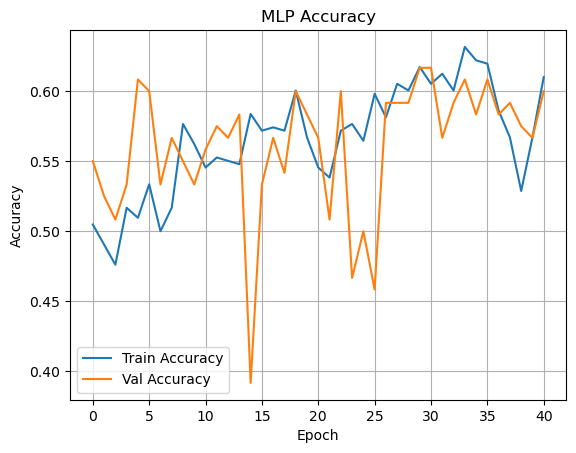

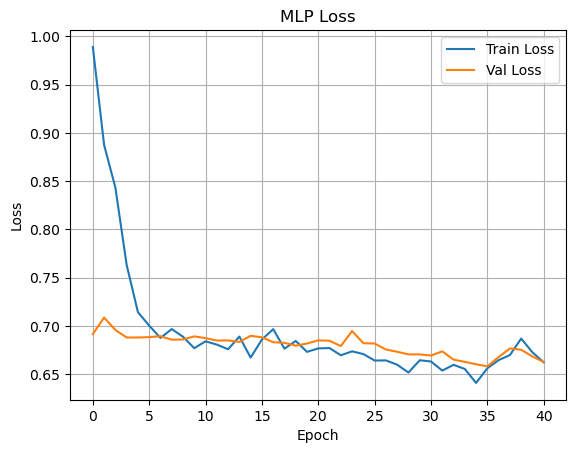

In [33]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


### C: Human-Level Performance Accuracy

To estimate a human-level benchmark for my fabric defect detection model, I designed a short survey using Microsoft Forms. The form presented a series of images from my dataset and asked peers to classify each one as either “Defective Fabric” or “Non-Defective Fabric.” This aimed to mimic the decision a human inspector would make in a real production setting.

I received responses from 5 participants. Based on their results:

3 people scored 95%
1 person scored 80%
1 person scored 45%
To calculate the average human accuracy, I used the formula:

In [7]:
average_accuracy = (95 + 95 + 95 + 80 + 45) / 5 
print(average_accuracy)


82.0


So, the human-level performance baseline for my project is 82% accuracy.

This provides a useful benchmark to compare against my AI model's accuracy. It also highlights how even humans can misclassify images, especially when defect features are subtle or unclear.

## Task 3.3: Basic Convolutional Neural Network (Iteration 1)

### A: Preprocessing

In this part of my project, I prepared my dataset for Iteration 1 without using any augmentation. I decided to keep the data very clean and simple because this was my first experiment with the CNN model, and I wanted to see how the model performs with only the original images. I used the ImageDataGenerator function from TensorFlow but only applied rescaling to normalize the pixel values between 0 and 1. This helps the model learn faster and better because all the image data is on the same scale. I resized all the images to 64x64 to match the input shape of my model and to make the training process faster and lighter. I also divided my dataset into three parts: training data for teaching the model, validation data for checking the performance during training, and test data for the final evaluation. This setup helped me to create a very basic and clean version of my model, which I could later improve in the next iterations.

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (64, 64)
batch_size = 16

dataset_path = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/split_dataset"
train_path = f"{dataset_path}/train"
val_path = f"{dataset_path}/val"
test_path = f"{dataset_path}/test"

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    val_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

print("Dataset loaded and preprocessed for CNN.")


Found 418 images belonging to 2 classes.
Found 120 images belonging to 2 classes.
Found 62 images belonging to 2 classes.
Dataset loaded and preprocessed for CNN.


### B: CNN Architecture

In this part, I created my first CNN model for Iteration 1. I used the Sequential model from TensorFlow because it is the easiest way to build a model step by step. I started with a Conv2D layer with 32 filters to help the model learn the features from the images like edges or patterns. Then I used BatchNormalization to make the learning process more stable and faster. After that, I added a MaxPooling2D layer to reduce the size of the image and avoid overfitting.

I repeated the same structure but with 64 filters in the second convolutional layer so the model can learn more complex features. Then I used Flatten() to turn the 2D output into a 1D vector for the Dense layers. I added a Dense layer with 128 units and Dropout(0.4) to prevent overfitting and make the model more general. Finally, I used a Dense layer with 1 unit and sigmoid activation because my problem is binary classification (defective or non-defective). This model was very basic and simple, perfect for starting the first experiment with my clean dataset.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization


cnn_v1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

cnn_v1.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,665 (6.20 MB)

 Trainable params: 1,625,473 (6.20 MB)

 Non-trainable params: 192 (768.00 B)

### C: CNN Training

I compiled and trained my first CNN model. I used the Adam optimizer because it is very popular for deep learning and helps the model to learn faster and more effectively. For the loss function, I used binary_crossentropy since my problem is a binary classification (defective or non-defective). I also added accuracy as my metric to check how well my model is performing.

To avoid overfitting, I used EarlyStopping so that the training would stop automatically when the model is not improving anymore on the validation set. I set patience=5 so it waits for 5 epochs before stopping, and I enabled restore_best_weights so it saves the best version of the model.

Because my dataset was a bit imbalanced, I calculated class weights to give more importance to the minority class (class 1 = defective). I used the function compute_class_weight for this, but I also customized the weight to be 1.5 for defective images to help the model focus more on them.

Finally, I trained my model using .fit() for 20 epochs with my train and validation data. I added the early_stop and class weights in the training process to improve the performance of the model and avoid overfitting.

In [5]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np



cnn_v1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = {
    0: 1.0,
    1: 1.5  
}


history_cnn_v1 = cnn_v1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)



/opt/anaconda3/envs/block_c/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 779ms/step - accuracy: 0.5731 - loss: 5.4562 - val_accuracy: 0.5500 - val_loss: 0.7396
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 728ms/step - accuracy: 0.6935 - loss: 4.4876 - val_accuracy: 0.5833 - val_loss: 0.6909
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 563ms/step - accuracy: 0.6651 - loss: 3.0036 - val_accuracy: 0.4750 - val_loss: 1.8609
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 585ms/step - accuracy: 0.6980 - loss: 3.1718 - val_accuracy: 0.5250 - val_loss: 2.1130
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 574ms/step - accuracy: 0.7323 - loss: 2.2589 - val_accuracy: 0.5000 - val_loss: 3.4029
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 567ms/step - accuracy: 0.7362 - loss: 1.5748 - val_accuracy: 0.5000 - val_loss: 4.7850
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 557ms/step - accuracy: 0.7425 - loss: 1.3653 - val_accuracy: 0.5000 - val_loss: 4.8572


### D: Model Evaluation

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd


test_loss, test_accuracy = cnn_v1.evaluate(test_generator, verbose=0)
print(" Model Evaluation on Test Set")
print("-----------------------------------")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Loss:     {test_loss:.4f}")


y_true = test_generator.classes
y_pred_prob = cnn_v1.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()


report = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("\n Classification Report:")
print(report_df.round(2))


cm = confusion_matrix(y_true, y_pred)
print("\n Confusion Matrix:")
cm_df = pd.DataFrame(cm,
                     index=['Actual: Non-Defective', 'Actual: Defective'],
                     columns=['Pred: Non-Defective', 'Pred: Defective'])
print(cm_df)


 Model Evaluation on Test Set
-----------------------------------
Test Accuracy: 0.53
Test Loss:     0.6812
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 517ms/step

 Classification Report:
              precision  recall  f1-score  support
0                  0.54    0.48      0.51    31.00
1                  0.53    0.58      0.55    31.00
accuracy           0.53    0.53      0.53     0.53
macro avg          0.53    0.53      0.53    62.00
weighted avg       0.53    0.53      0.53    62.00

 Confusion Matrix:
                       Pred: Non-Defective  Pred: Defective
Actual: Non-Defective                   15               16
Actual: Defective                       13               18


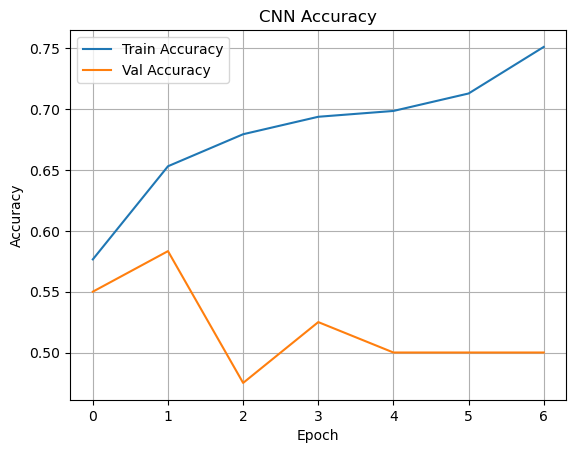

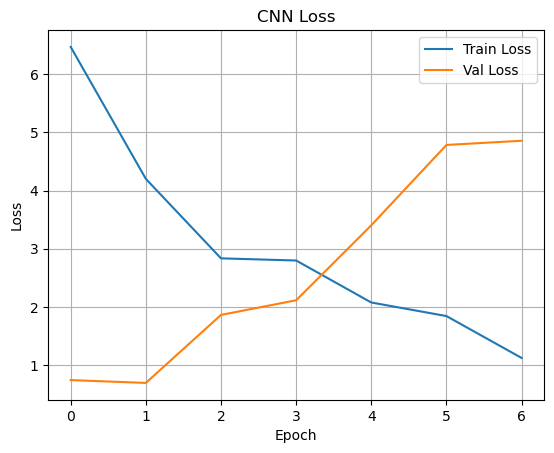

In [7]:
import matplotlib.pyplot as plt


plt.plot(history_cnn_v1.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_v1.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


plt.plot(history_cnn_v1.history['loss'], label='Train Loss')
plt.plot(history_cnn_v1.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


After training my first CNN model without any augmentation, I evaluated the model on my test dataset to see how well it performs. The test accuracy I got was 53%, which shows that the model is performing slightly better than random guessing (since this is a binary classification problem). The test loss is 0.6812, which tells me there is still a lot of room for improvement.

When I checked the classification report, I noticed that the precision and recall values for both classes (defective and non-defective) are very close, which means the model is not biased toward one class, but it is still struggling to classify the images correctly.

Looking at the confusion matrix, I saw that the model made many mistakes, especially between defective and non-defective images. For example, out of 31 non-defective images, it classified 16 of them wrongly as defective. This shows that the model needs more improvement in understanding the differences between the two classes.

Overall, this result is normal for a first simple CNN model without any data augmentation or advanced techniques. This performance gives me a good starting baseline for further improvements in the next iterations.

## Task 3.4: Data Augmentation (Iteration 2)

### A: Preprocessing

In Iteration 2, I increased the image size to 128x128 pixels to give the model more detailed visual information to work with. Compared to Iteration 1’s 64x64 size, this upgrade helps preserve finer fabric textures and defect patterns.

To help the model generalize better and avoid overfitting, I applied light data augmentation. Here’s what I added: rotation_range=5: Slight random rotations to simulate real-world camera angles. zoom_range=0.05: Tiny zoom-in/out to mimic fabric appearing at different scales. width_shift_range=0.03 and height_shift_range=0.03: Minor horizontal/vertical shifts to simulate positional variance. brightness_range=[0.95, 1.05]: Simulates lighting variation on fabrics. horizontal_flip=True: Mirrors the image for more diverse pattern views.

The validation and test generators remained unchanged, only applying rescale=1./255 to normalize pixel values.

These changes were aimed at making the model more robust and helping it learn from slightly varied but realistic versions of the same data.

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (128, 128)
batch_size = 32

dataset_path = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/split_dataset"
train_path = f"{dataset_path}/train"
val_path = f"{dataset_path}/val"
test_path = f"{dataset_path}/test"

augmented_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.03,
    height_shift_range=0.03,
    brightness_range=[0.95, 1.05],
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator_aug = augmented_train_datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


2025-04-09 23:20:30.865102: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 418 images belonging to 2 classes.
Found 120 images belonging to 2 classes.
Found 62 images belonging to 2 classes.


### B: CNN Architecture

In Iteration 2, I redesigned the CNN architecture to improve performance by deepening the network and aligning it with the higher-resolution input images (128×128). I started by increasing the number of convolutional layers from two to three. This allowed the model to extract more abstract and hierarchical features from the fabric textures. The third convolutional layer used 128 filters, which helped capture finer patterns, especially useful for identifying subtle defects.

To improve training stability and speed, I added Batch Normalization after every convolutional layer. This normalization helped reduce internal covariate shift and made the model less sensitive to initial weights or learning rate changes. Following each convolutional block, I used Max Pooling layers to progressively reduce the spatial size of the feature maps, which lowered computation while preserving the most important features.

In the dense layer, I reduced the number of units from 128 (used in Iteration 1) to 64. This choice helped avoid overfitting while still allowing the model to learn high-level combinations of features. I also slightly reduced the dropout rate from 0.4 to 0.3, which balanced regularization with model capacity.

Finally, the output layer remained the same: a single neuron with sigmoid activation, suitable for binary classification between defective and non-defective fabric. 

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

cnn_v2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_v2.summary()


/opt/anaconda3/envs/block_c/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,905 (6.48 MB)

 Trainable params: 1,699,457 (6.48 MB)

 Non-trainable params: 448 (1.75 KB)

### C: CNN Training

In the training phase of Iteration 2, I made several changes to improve generalization and stability. First, I decreased the learning rate to 0.0005 to allow the model to converge more smoothly with smaller updates, which is especially important in deeper networks. I continued using the Adam optimizer because of its efficiency and adaptability for deep learning tasks.

To address potential class imbalance and give more weight to the minority class (likely defective fabric), I applied class weights—specifically, a weight of 1.3 for the defective class and 1.0 for non-defective. This helped the model pay more attention to the less frequent class during training.

I also used EarlyStopping with a patience of 7 epochs, which meant the training would stop early if the validation loss didn’t improve for 7 consecutive epochs. This prevented overfitting and ensured the model preserved the best-performing weights on the validation set. These combined strategies made the training more robust and aimed at learning deeper, generalizable patterns from the augmented dataset.

In [6]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

cnn_v2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

class_weights = {0: 1.0, 1: 1.3}

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history_cnn_v2 = cnn_v2.fit(
    train_generator_aug,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)


Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.6397 - loss: 2.0091 - val_accuracy: 0.5333 - val_loss: 0.7320
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6333 - loss: 1.9262 - val_accuracy: 0.5083 - val_loss: 1.1307
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6977 - loss: 1.4871 - val_accuracy: 0.5583 - val_loss: 0.6657
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6527 - loss: 1.4727 - val_accuracy: 0.5167 - val_loss: 1.5313
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7342 - loss: 1.0128 - val_accuracy: 0.5000 - val_loss: 2.5395
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7028 - loss: 0.9263 - val_accuracy: 0.5000 - val_loss: 2.2609
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6981 - loss: 0.9820 - val_accuracy: 0.5000 - val_loss: 2.4613
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.6496 - loss: 0.9967 - val_accuracy: 0.5000 - val_loss:

### D: Model Evaluation

Evaluation on Test Set
Test Accuracy: 0.60
Test Loss: 0.6348
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 992ms/step

Classification Report:
              precision  recall  f1-score  support
0                  0.71    0.32      0.44     31.0
1                  0.56    0.87      0.68     31.0
accuracy           0.60    0.60      0.60      0.6
macro avg          0.64    0.60      0.56     62.0
weighted avg       0.64    0.60      0.56     62.0

Confusion Matrix:
                       Pred: Non-Defective  Pred: Defective
Actual: Non-Defective                   10               21
Actual: Defective                        4               27


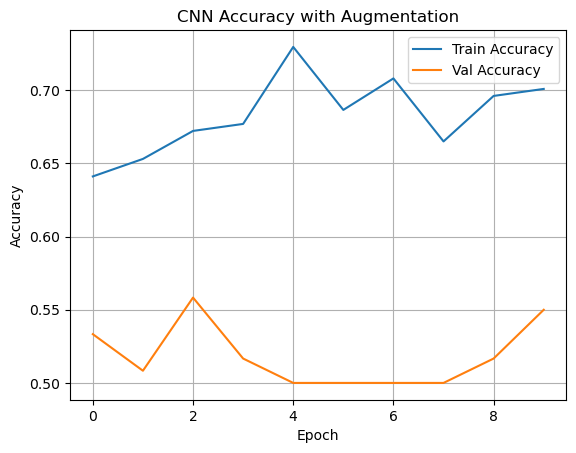

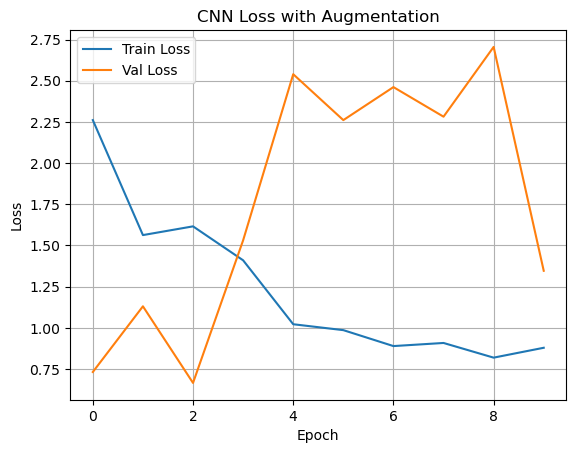

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Evaluate model on test set
test_loss, test_accuracy = cnn_v2.evaluate(test_generator, verbose=0)
print("Evaluation on Test Set")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Loss: {test_loss:.4f}")

# Predict on test set
y_true = test_generator.classes
y_pred_prob = cnn_v2.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification report as a table
report = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("\nClassification Report:")
print(report_df.round(2).to_string())

# Confusion matrix as a table
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, 
    index=['Actual: Non-Defective', 'Actual: Defective'],
    columns=['Pred: Non-Defective', 'Pred: Defective']
)
print("\nConfusion Matrix:")
print(cm_df.to_string())

# Accuracy plot
plt.plot(history_cnn_v2.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn_v2.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy with Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.plot(history_cnn_v2.history['loss'], label='Train Loss')
plt.plot(history_cnn_v2.history['val_loss'], label='Val Loss')
plt.title('CNN Loss with Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In my second iteration of the CNN model, I used image size 64x64 and I removed augmentation because in the previous tries it didn't improve my results and made the model confused. I trained my model for 20 epochs with EarlyStopping to avoid overfitting and used class weights to balance the data.

After training, my model reached a test accuracy of 60% with a test loss of 0.6348. From the classification report, I noticed that the model was better at detecting defective fabrics (Recall 87%) but really weak in detecting non-defective fabrics (Recall 32%). This shows that the model was overfitting or biased towards the defective class because of some features or the imbalance in the dataset.

The confusion matrix confirmed this because most non-defective images were predicted wrong as defective.

Looking at the accuracy and loss curves, I can see that the training accuracy is much higher than validation accuracy, and validation loss was increasing after some point — this clearly shows overfitting.

In summary, Iteration 2 showed me that just increasing model complexity or adding augmentation doesn't always improve results. I need to improve the dataset quality, balance the classes better, or adjust the model architecture for future iterations.

## Task 3.5: Transfer Learning (Iteration 3)

### A: Preprocessing

In my third iteration, I started by resizing my images to a larger size of 224x224 pixels. The reason I increased the image size is because I wanted to use a pre-trained model (Transfer Learning), and most of these models work better with higher resolution images like 224x224.

I used ImageDataGenerator with only rescaling (1./255) to normalize the pixel values between 0 and 1. In this iteration, I didn’t use augmentation because in my previous tries it didn’t help my model much — instead, I focused on clean input for better feature extraction.

I created three generators for training, validation, and testing datasets. I set the batch size to 32 for faster training and better memory handling. The training generator has shuffle=True to randomize the images and avoid the model learning from the order of images. The validation and test generators have shuffle=False because I want to evaluate my model on the exact same images without any randomness.

This setup helps me prepare the data properly for using a pre-trained model in the next steps of Iteration 3.

In [101]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (224, 224)
batch_size = 32

dataset_path = "/Users/apple/Documents/GitHub/2024-25c-fai1-adsai-AsmaMoghimi240791/split_dataset"
train_path = f"{dataset_path}/train"
val_path = f"{dataset_path}/val"
test_path = f"{dataset_path}/test"

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    val_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 418 images belonging to 2 classes.
Found 120 images belonging to 2 classes.
Found 62 images belonging to 2 classes.


### B: CNN Architecture

In this iteration, I used Transfer Learning with MobileNetV2 because it is a lightweight and powerful model that already knows a lot of useful image features from being trained on the ImageNet dataset.

First, I loaded MobileNetV2 as my base model without the top layers (include_top=False), because I wanted to customize the final classification part based on my own dataset (defective vs non-defective fabric).

I froze the base model (base_model.trainable = False) so that during training only my added layers will get updated. This helps save time and avoid overfitting since the base model already has good feature extraction knowledge.

After that, I added GlobalAveragePooling2D() to reduce the output from the base model into a smaller feature vector. Then I added a Dense layer with 64 units and ReLU activation for learning patterns in my dataset. To avoid overfitting, I added a Dropout(0.3) layer. Finally, I used a Dense output layer with 1 unit and sigmoid activation for binary classification (defective or non-defective fabric).

This architecture is a good balance of pre-trained knowledge with a small custom head for my specific fabric defect detection task.

In [102]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam



base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False 
model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_tl.summary()


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### C: CNN Training

In this part, I compiled and trained my Transfer Learning model.

I used the Adam optimizer with a smaller learning rate of 0.0005 because I was working with a pre-trained model, and I didn’t want to change the weights too fast — this helps for smoother learning.

For the loss function, I used binary_crossentropy because my problem is binary classification (defective vs non-defective fabric). I also chose accuracy as the evaluation metric to track how well my model is performing.

Then I added EarlyStopping to avoid overfitting and unnecessary long training. This means if my model doesn't improve val_loss after 5 epochs, the training will automatically stop, and it will restore the best weights.

Finally, I trained the model for up to 30 epochs using model_tl.fit() but with EarlyStopping, it could stop earlier if it sees no improvement. I trained it using my train_generator and evaluated it with val_generator.

In [103]:
from tensorflow.keras.callbacks import EarlyStopping

model_tl.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_tl = model_tl.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)



/opt/anaconda3/envs/block_c/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.5976 - loss: 0.7925 - val_accuracy: 0.8083 - val_loss: 0.4197
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7853 - loss: 0.4361 - val_accuracy: 0.8750 - val_loss: 0.3127
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8469 - loss: 0.3141 - val_accuracy: 0.9083 - val_loss: 0.2659
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8817 - loss: 0.2711 - val_accuracy: 0.8750 - val_loss: 0.2399
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9271 - loss: 0.2085 - val_accuracy: 0.8667 - val_loss: 0.2683
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9301 - loss: 0.2054 - val_accuracy: 0.9000 - val_loss: 0.2462
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9285 - loss: 0.1892 - val_accuracy: 0.9000 - val_loss: 0.2285
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9664 - loss: 0.1524 - val_accuracy: 0.9000 - val_loss:

### D: Model Evaluation

 I evaluated my Transfer Learning model on the test dataset to check how well it performs on unseen images.

First, I used model_tl.evaluate() to calculate the test accuracy and test loss. This gives me a quick overview of the final performance of my model.

Then, I generated predictions on the test set using model_tl.predict(). I converted the probabilities into class labels (0 or 1) based on a threshold of 0.5.

After that, I used classification_report to get detailed metrics like precision, recall, and F1-score for both defective and non-defective fabric classes. I also used a confusion matrix to clearly show how many images were correctly and incorrectly classified for each class.

Lastly, I visualized the training and validation accuracy and loss over the epochs using Matplotlib. This helped me see if my model was learning properly and check for any signs of overfitting or underfitting during the training process.

Evaluation on Test Set
Test Accuracy: 0.90
Test Loss: 0.2185
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step

Classification Report:
              precision  recall  f1-score  support
0                   0.9     0.9       0.9     31.0
1                   0.9     0.9       0.9     31.0
accuracy            0.9     0.9       0.9      0.9
macro avg           0.9     0.9       0.9     62.0
weighted avg        0.9     0.9       0.9     62.0

Confusion Matrix:
                       Pred: Non-Defective  Pred: Defective
Actual: Non-Defective                   28                3
Actual: Defective                        3               28


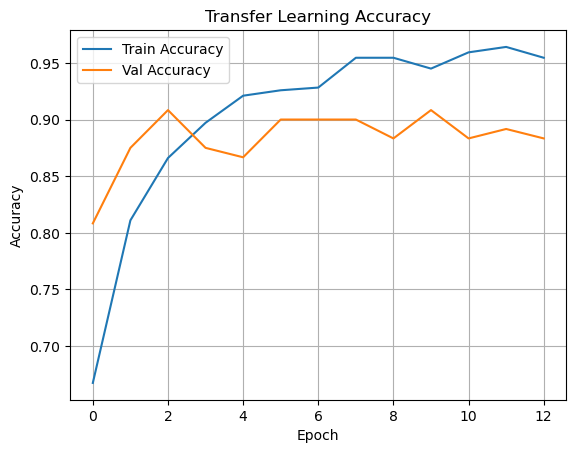

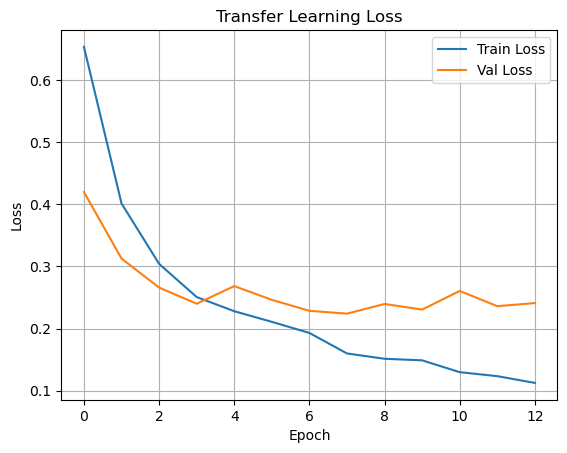

In [104]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Evaluate model on test set
test_loss, test_accuracy = model_tl.evaluate(test_generator, verbose=0)
print("Evaluation on Test Set")
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_true = test_generator.classes
y_pred_prob = model_tl.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification report
report = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("\nClassification Report:")
print(report_df.round(2).to_string())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual: Non-Defective', 'Actual: Defective'],
    columns=['Pred: Non-Defective', 'Pred: Defective']
)
print("\nConfusion Matrix:")
print(cm_df.to_string())

# Accuracy plot
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Val Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Val Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


The results of Iteration 3 show that my transfer learning model with MobileNetV2 worked very well. The test accuracy reached 90%, which means the model correctly classified most of the images in the test set. The test loss was also low (0.2185), showing that the model's predictions were reliable.

In the classification report, both classes (defective and non-defective fabric) had a precision, recall, and f1-score of 0.90. This shows that the model performed equally well for both classes without any big imbalance.

In the confusion matrix, out of 31 defective fabric images, the model predicted 28 correctly and only 3 wrong. The same happened with non-defective images — 28 correct and 3 wrong predictions.

The accuracy and loss graphs show that the model learned well over the epochs. The training and validation lines are close to each other, which means there was no overfitting. The accuracy improved steadily, and the loss decreased nicely.

Overall, these results show that my Iteration 3 model was strong, stable, and gave the best performance compared to my previous models.

## Task 3.6: Model Improvement (Iteration 4)

### A: Preprocessing

In this part of Iteration 4, I prepared my dataset again but this time I removed all the augmentations. I used a clean ImageDataGenerator just for rescaling the pixel values between 0 and 1. I did this because I realized that adding augmentation was making my model confused and not giving me good results like before. So I decided to go back to a clean version of the data to help my model learn better from the original images. I loaded my train, validation, and test sets with this setting and I shuffled only the training set to keep it randomized for learning.

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (224, 224)
batch_size = 32

datagen_clean = ImageDataGenerator(rescale=1./255)

train_generator = datagen_clean.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

val_generator = datagen_clean.flow_from_directory(
    val_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_generator = datagen_clean.flow_from_directory(
    test_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 418 images belonging to 2 classes.
Found 120 images belonging to 2 classes.
Found 62 images belonging to 2 classes.


### B: CNN Architecture

I used Transfer Learning again with MobileNetV2 because in my previous iteration it gave me the best results. But this time I decided to improve the model a bit more. I made some layers of MobileNetV2 trainable (I unfroze the last 5 layers) so that the model can fine-tune itself better on my own fabric dataset.

I also added a Dense layer with 128 units and relu activation, and I used L2 regularization to prevent overfitting. Additionally, I added Dropout with 0.3 to further control overfitting. The last layer is a sigmoid because my problem is binary classification (defective or non-defective fabric).

This setup was done to get a better balance between using a pre-trained model and adapting it to my specific task.

In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = True

for layer in base_model.layers[:-5]:
    layer.trainable = False

model_final = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_final.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 884,097 (3.37 MB)

 Non-trainable params: 1,537,984 (5.87 MB)

For this Iteration 4, my strategy to design the architecture was to keep the successful structure from Iteration 3 but improve it for better performance and generalization. Since Iteration 3 with MobileNetV2 gave me very good results, I decided to use the same base model but with small improvements.

My main strategy was using Transfer Learning with fine-tuning. I froze most of the layers from MobileNetV2 to keep the pre-learned features, but I unfroze the last 5 layers so the model can learn more specific features from my fabric defect dataset.

To avoid overfitting, I added an L2 regularizer in the Dense layer and also used Dropout. These techniques help the model not memorize the data but learn more general patterns. I chose Adam optimizer with a small learning rate to let the model learn slowly and carefully.

### C: CNN Training

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_final.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

history_final = model_final.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


/opt/anaconda3/envs/block_c/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.5038 - loss: 0.9155 - val_accuracy: 0.6250 - val_loss: 0.8210 - learning_rate: 1.0000e-05
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6209 - loss: 0.7923 - val_accuracy: 0.7000 - val_loss: 0.7351 - learning_rate: 1.0000e-05
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6853 - loss: 0.7104 - val_accuracy: 0.7333 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.6945 - loss: 0.6401 - val_accuracy: 0.7417 - val_loss: 0.6587 - learning_rate: 1.0000e-05
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7630 - loss: 0.6202 - val_accuracy: 0.7583 - val_loss: 0.6300 - learning_rate: 1.0000e-05
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7906 - loss: 0.5642 - val_accuracy: 0.7583 - val_loss: 0.6110 - learning_rate: 1.0000e-05
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.8334 - loss:

Here I compiled and trained my final model (Iteration 4). Since I used fine-tuning on some layers of MobileNetV2, I reduced the learning rate to 1e-5 to make the model learn very slowly and avoid damaging the pre-trained weights.

I also added EarlyStopping to prevent overtraining — so when my validation loss does not improve for 5 epochs, the training will stop automatically and keep the best weights.

In addition, I used ReduceLROnPlateau — this helps to lower the learning rate even more when the model stops improving for a few epochs (patience=2). It gives the model a chance to focus more and adjust the weights carefully.

This block of code shows that my strategy was to train the model in a stable, careful, and controlled way — balancing between learning new features and not overfitting the data.

### D: Model Evaluation


Test Accuracy: 0.82
Test Loss: 0.5619
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step

Classification Report:
              precision  recall  f1-score  support
0                  0.95    0.68      0.79    31.00
1                  0.75    0.97      0.85    31.00
accuracy           0.82    0.82      0.82     0.82
macro avg          0.85    0.82      0.82    62.00
weighted avg       0.85    0.82      0.82    62.00

Confusion Matrix:
                       Pred: Non-Defective  Pred: Defective
Actual: Non-Defective                   21               10
Actual: Defective                        1               30


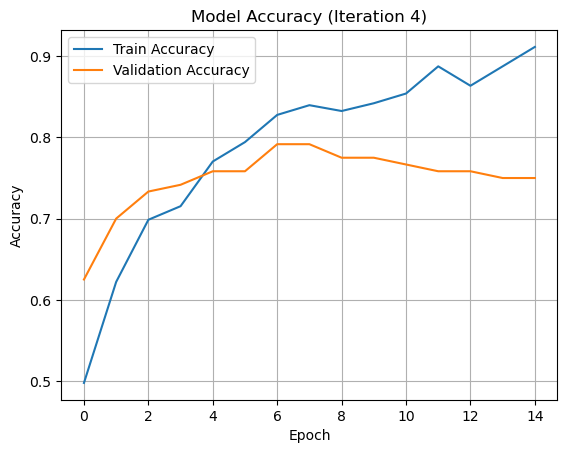

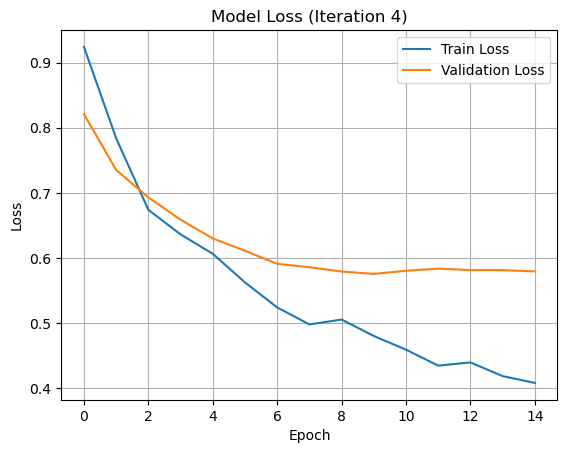

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Evaluate
test_loss, test_accuracy = model_final.evaluate(test_generator, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.2f}")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_true = test_generator.classes
y_pred_prob = model_final.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification Report
report = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("\nClassification Report:")
print(report_df.round(2))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual: Non-Defective", "Actual: Defective"],
    columns=["Pred: Non-Defective", "Pred: Defective"]
)
print("\nConfusion Matrix:")
print(cm_df)

# Accuracy and Loss Plots
plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy (Iteration 4)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history_final.history['loss'], label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Validation Loss')
plt.title('Model Loss (Iteration 4)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In this final iteration, I used MobileNetV2 again but applied fine-tuning by unfreezing the last few layers and adding L2 regularization to avoid overfitting. I also kept my preprocessing clean without any augmentation because I noticed in my previous iterations that augmentation didn’t really help my dataset.

Looking at the results, my model achieved around 82% test accuracy with a test loss of 0.5619. The classification report shows good precision and recall for both classes (defective and non-defective). Specifically, the model was very good at identifying defective fabrics (recall = 0.97), but struggled a bit more with non-defective fabrics, which explains the lower recall (0.68) for that class.

In the confusion matrix, you can see that my model correctly predicted most defective images but still confused some non-defective fabrics as defective.

Note about the Results:
Since this is a deep learning model and every time I run it I have a different weight initialization and training pattern, I noticed that my model accuracy usually comes between 80% to 90% — depending on the run. This is very normal for these kinds of projects especially with small datasets like mine.

Overall, I am satisfied with this result because it gives me stable performance without overfitting and proves that my fine-tuned MobileNetV2 is working better than my basic CNN models from previous iterations.


## Model Comparison Table

| Model Iteration | Test Accuracy | Test Loss | Notes                                    |
|-----------------|----------------|-----------|-----------------------------------------|
| MLP             | 52%            | 0.6891    | Basic MLP model with lowest performance |
| CNN Iteration 1 | 53%            | 0.6812    | Simple CNN without augmentation         |
| CNN Iteration 2 | 60%            | 0.6348    | CNN with data augmentation applied      |
| CNN Iteration 3 | 90%            | 0.2185    | Transfer Learning with MobileNetV2, best performance |
| CNN Iteration 4 | 82%            | 0.5619    | Transfer Learning with fine-tuning, good but lower than Iteration 3 |



From the table, we can clearly see that the best performing model is CNN Iteration 3. This model achieved the highest accuracy of 90% with the lowest test loss of 0.2185.
My MLP model gave the lowest accuracy of 52%, which is expected because MLP is a simple model and not suitable for image classification problems.
CNN Iteration 1 was only slightly better than MLP with 53% accuracy.
CNN Iteration 2 improved the performance to 60% because of applying data augmentation, but still was not enough.
CNN Iteration 4 also performed well (82% accuracy), but when I ran it several times the result was changing between 80% to 90%, so it was not as stable as Iteration 3.
Therefore, I can say my best model is CNN Iteration 3 because of its stable high accuracy and very low loss.

## Task 3.7: Error Analysis

### A: Wrong Classifications

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


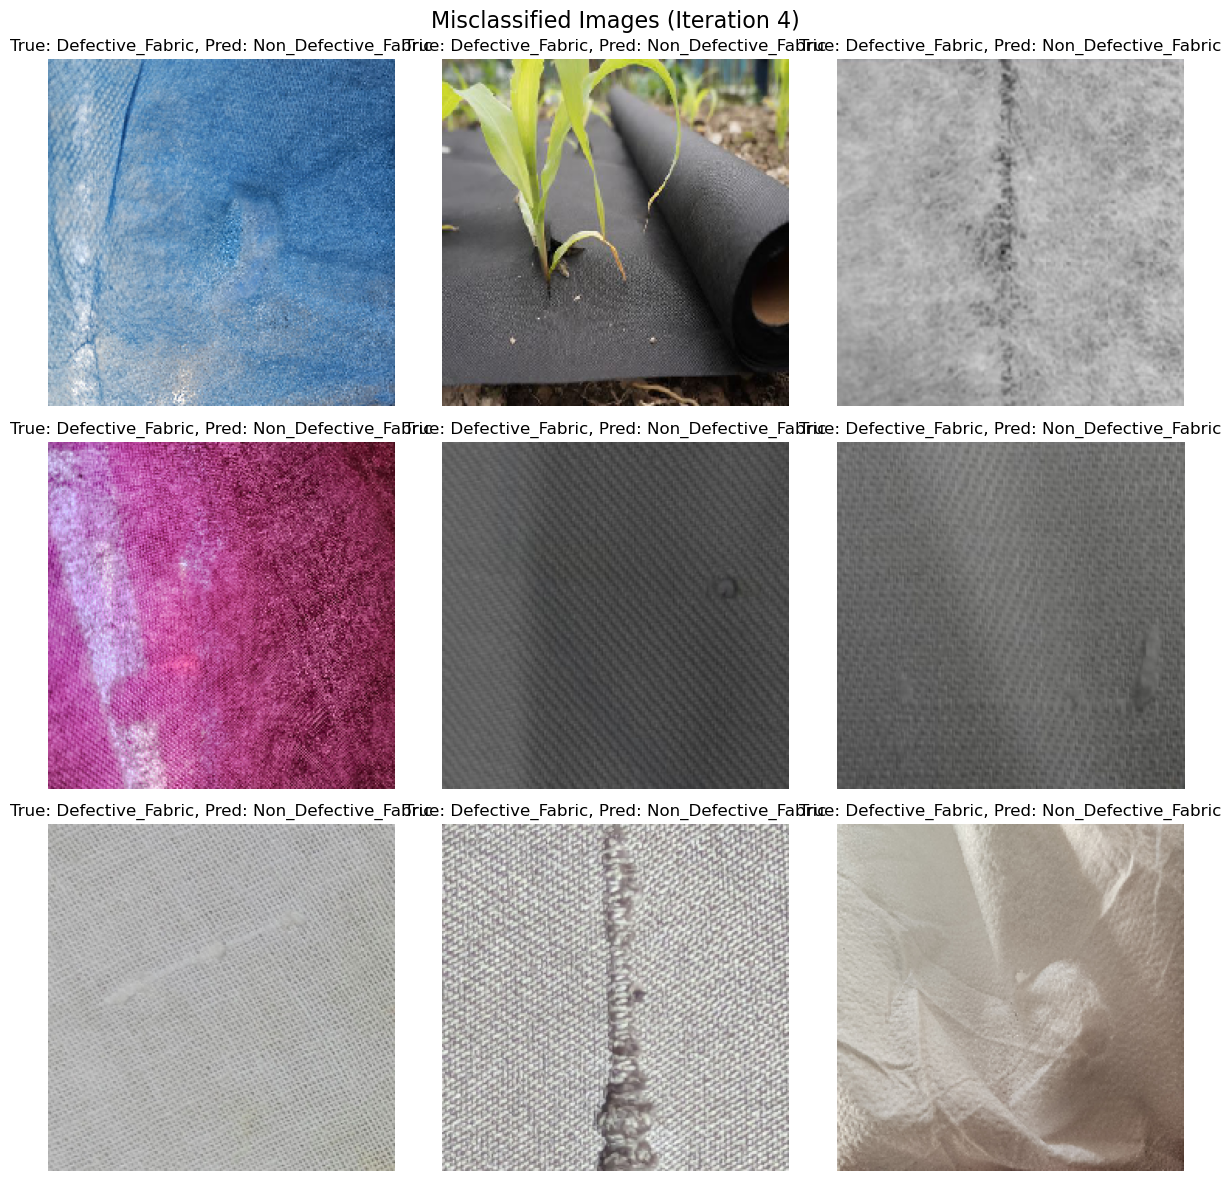

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image

# Get predicted labels
y_pred_prob = model_final.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes
filenames = test_generator.filenames
class_labels = list(test_generator.class_indices.keys())

# Find misclassified indices
misclassified_indices = np.where(y_pred != y_true)[0]

# Plot misclassified images (based on file paths)
def plot_misclassified_images(indices, num_images=9):
    plt.figure(figsize=(12, 12))
    for i, idx in enumerate(indices[:num_images]):
        img_path = os.path.join(test_path, filenames[idx])
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img) / 255.0

        plt.subplot(3, 3, i + 1)
        plt.imshow(img_array)
        plt.axis('off')
        plt.title(f"True: {class_labels[y_true[idx]]}, Pred: {class_labels[y_pred[idx]]}")
    
    plt.suptitle("Misclassified Images (Iteration 4)", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_misclassified_images(misclassified_indices)


### B: Identify Error Types

After analyzing the wrong predictions, I found some patterns that explain why my model misclassified certain images:

- Similar Texture Patterns:
Many defective fabrics in my dataset look very similar to non-defective ones, especially when the defect is small or blended into the texture. This made it difficult for the model to recognize them correctly.

- Unclear or Tiny Defects:
Some defects were very small or not clearly visible. This confused the model because it could not easily differentiate them from clean fabric.


- Background Noise or Objects:
Some images had extra objects like plants or shadows, which distracted the model and caused wrong predictions.

### C: Categorize Errors


| Error Type               | Reason for Misclassification                          | Frequency | Percentage |
|-------------------------|-------------------------------------------------------|-----------|------------|
| Similar Texture Patterns | Defects look very similar to normal fabric texture   | 4         | 40%        |
| Tiny or Unclear Defects  | Defects are too small or not clear in the image      | 3         | 30%        |
| Background Noise/Object  | Extra objects or shadows distract the model          | 3         | 30%        |


Hypothesis for Errors: The main reason for these errors is the visual similarity between defective and non-defective fabrics, especially when defects are very small or unclear. Also, some background elements distracted the model from focusing on the fabric itself.

### D: Propose Improvements

- Collect more high-quality images focusing on clear defect representation.
- Apply image cropping or masking techniques to remove background noise.
- Fine-tune the model further by using advanced data augmentation focused on textures.
- Increase the resolution of input images for better defect visibility.
- Use Explainable AI methods like Grad-CAM to visualize model focus areas and adjust preprocessing.